In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

LOYALTY_FILE = RAW_DIR / "Customer Loyalty History.csv"
FLIGHT_FILE = RAW_DIR / "Customer Flight Activity.csv"
CALENDAR_FILE = RAW_DIR / "Calendar.csv"
DICT_FILE = RAW_DIR / "Airline Loyalty Data Dictionary.csv"

In [2]:
loyalty = pd.read_csv(LOYALTY_FILE)
flight = pd.read_csv(FLIGHT_FILE)
calendar = pd.read_csv(CALENDAR_FILE)
data_dict = pd.read_csv(DICT_FILE)

print("Loyalty:", loyalty.shape)
print("Flight:", flight.shape)
print("Calendar:", calendar.shape)
print("Dictionary:", data_dict.shape)

Loyalty: (16737, 16)
Flight: (392936, 8)
Calendar: (2557, 4)
Dictionary: (24, 3)


In [3]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df

loyalty = clean_columns(loyalty)
flight = clean_columns(flight)
calendar = clean_columns(calendar)
data_dict = clean_columns(data_dict)

print(loyalty.columns.tolist())
print(flight.columns.tolist())
print(calendar.columns.tolist())

['loyalty_number', 'country', 'province', 'city', 'postal_code', 'gender', 'education', 'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month', 'cancellation_year', 'cancellation_month']
['loyalty_number', 'year', 'month', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed']
['date', 'start_of_year', 'start_of_quarter', 'start_of_month']


In [4]:
flight["activity_date"] = pd.to_datetime(
    flight["year"].astype(int).astype(str) + "-" +
    flight["month"].astype(int).astype(str) + "-01"
)

loyalty["enrollment_date"] = pd.to_datetime(
    loyalty["enrollment_year"].astype(int).astype(str) + "-" +
    loyalty["enrollment_month"].astype(int).astype(str) + "-01"
)

loyalty["cancellation_date"] = pd.to_datetime(
    loyalty["cancellation_year"].astype("Int64").astype(str) + "-" +
    loyalty["cancellation_month"].astype("Int64").astype(str) + "-01",
    errors="coerce"
)

calendar["date"] = pd.to_datetime(calendar["date"])
calendar["start_of_year"] = pd.to_datetime(calendar["start_of_year"])
calendar["start_of_quarter"] = pd.to_datetime(calendar["start_of_quarter"])
calendar["start_of_month"] = pd.to_datetime(calendar["start_of_month"])

In [5]:
loyalty = loyalty.rename(columns={
    "loyalty_number": "customer_id",
    "postal_code": "postal_code",
    "marital_status": "marital_status",
    "loyalty_card": "loyalty_card",
    "enrollment_type": "enrollment_type",
    "enrollment_year": "enrollment_year",
    "enrollment_month": "enrollment_month",
    "cancellation_year": "cancellation_year",
    "cancellation_month": "cancellation_month",
})

flight = flight.rename(columns={
    "loyalty_number": "customer_id",
    "year": "year",
    "month": "month",
    "total_flights": "total_flights",
    "distance": "distance",
    "points_accumulated": "points_accumulated",
    "points_redeemed": "points_redeemed",
    "dollar_cost_points_redeemed": "dollar_cost_points_redeemed",
})

In [6]:
num_cols_loyalty = ["salary", "clv", "enrollment_year", "enrollment_month", "cancellation_year", "cancellation_month"]
for col in num_cols_loyalty:
    if col in loyalty.columns:
        loyalty[col] = pd.to_numeric(loyalty[col], errors="coerce")

num_cols_flight = ["year", "month", "total_flights", "distance", "points_accumulated", "points_redeemed", "dollar_cost_points_redeemed"]
for col in num_cols_flight:
    flight[col] = pd.to_numeric(flight[col], errors="coerce")

In [7]:
print("Duplicate customers in loyalty:", loyalty["customer_id"].duplicated().sum())
print("Duplicate rows in flight:", flight.duplicated().sum())

print("\nMissing values in loyalty:")
print(loyalty.isna().sum().sort_values(ascending=False).head(20))

print("\nMissing values in flight:")
print(flight.isna().sum().sort_values(ascending=False).head(20))

Duplicate customers in loyalty: 0
Duplicate rows in flight: 1922

Missing values in loyalty:
cancellation_year     14670
cancellation_date     14670
cancellation_month    14670
salary                 4238
country                   0
customer_id               0
gender                    0
province                  0
postal_code               0
city                      0
loyalty_card              0
marital_status            0
education                 0
clv                       0
enrollment_month          0
enrollment_year           0
enrollment_type           0
enrollment_date           0
dtype: int64

Missing values in flight:
customer_id                    0
year                           0
month                          0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
activity_date                  0
dtype: int64


In [8]:
analysis_end_date = flight["activity_date"].max()

customer_flight = (
    flight.groupby("customer_id", as_index=False)
    .agg(
        flight_months=("activity_date", "nunique"),
        first_activity=("activity_date", "min"),
        last_activity=("activity_date", "max"),
        total_flights=("total_flights", "sum"),
        total_distance=("distance", "sum"),
        total_points_accumulated=("points_accumulated", "sum"),
        total_points_redeemed=("points_redeemed", "sum"),
        total_redeemed_dollars=("dollar_cost_points_redeemed", "sum"),
        avg_flights_per_month=("total_flights", "mean"),
        avg_monthly_distance=("distance", "mean"),
    )
)

customer_flight["recency_months"] = (
    (analysis_end_date.to_period("M") - customer_flight["last_activity"].dt.to_period("M"))
    .apply(lambda x: x.n)
)

customer_flight["activity_span_months"] = (
    (customer_flight["last_activity"].dt.to_period("M") - customer_flight["first_activity"].dt.to_period("M"))
    .apply(lambda x: x.n) + 1
)

customer_flight["points_redemption_ratio"] = (
    customer_flight["total_points_redeemed"] / customer_flight["total_points_accumulated"].replace(0, np.nan)
)

customer_flight["flights_per_active_month"] = (
    customer_flight["total_flights"] / customer_flight["flight_months"].replace(0, np.nan)
)

customer_flight["distance_per_flight"] = (
    customer_flight["total_distance"] / customer_flight["total_flights"].replace(0, np.nan)
)

In [9]:
customer_df = loyalty.merge(customer_flight, on="customer_id", how="left")
print(customer_df.shape)
customer_df.head()

(16737, 33)


,customer_id,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,enrollment_date,cancellation_date,flight_months,first_activity,last_activity,total_flights,total_distance,total_points_accumulated,total_points_redeemed,total_redeemed_dollars,avg_flights_per_month,avg_monthly_distance,recency_months,activity_span_months,points_redemption_ratio,flights_per_active_month,distance_per_flight
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2016-02-01,NaT,24,2017-01-01,2018-12-01,37,54525,54525.0,1418,256,1.541667,2271.875000,0,24,0.026006,1.541667,1473.648649
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,2016-03-01,NaT,24,2017-01-01,2018-12-01,58,77487,77487.0,1971,356,2.416667,3228.625000,0,24,0.025437,2.416667,1335.982759
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,2014-07-01,2018-01-01,24,2017-01-01,2018-12-01,18,24803,24803.0,374,67,0.750000,1033.458333,0,24,0.015079,0.750000,1377.944444
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,2013-02-01,NaT,24,2017-01-01,2018-12-01,35,48432,48432.0,1291,233,1.458333,2018.000000,0,24,0.026656,1.458333,1383.771429
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,2014-10-01,NaT,24,2017-01-01,2018-12-01,37,55515,55515.0,0,0,1.541667,2313.125000,0,24,0.000000,1.541667,1500.405405


In [10]:
customer_df["official_churn"] = customer_df["cancellation_date"].notna().astype(int)
customer_df["behavioral_churn"] = np.where(customer_df["recency_months"] >= 6, 1, 0)
customer_df["churn"] = customer_df["official_churn"]

customer_df["salary_imputed"] = customer_df["salary"].fillna(customer_df["salary"].median())

customer_df["tenure_months"] = (
    (2018 - customer_df["enrollment_year"]) * 12
    + (12 - customer_df["enrollment_month"])
)

customer_df["distance_per_flight"] = customer_df["distance_per_flight"].fillna(0)
customer_df["points_redemption_ratio"] = customer_df["points_redemption_ratio"].fillna(0)

customer_df = customer_df.replace([np.inf, -np.inf], np.nan)
customer_df["distance_per_flight"] = customer_df["distance_per_flight"].fillna(0)
customer_df["points_redemption_ratio"] = customer_df["points_redemption_ratio"].fillna(0)

customer_df.head()

,customer_id,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,enrollment_date,cancellation_date,flight_months,first_activity,last_activity,total_flights,total_distance,total_points_accumulated,total_points_redeemed,total_redeemed_dollars,avg_flights_per_month,avg_monthly_distance,recency_months,activity_span_months,points_redemption_ratio,flights_per_active_month,distance_per_flight,official_churn,behavioral_churn,churn,salary_imputed,tenure_months
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2016-02-01,NaT,24,2017-01-01,2018-12-01,37,54525,54525.0,1418,256,1.541667,2271.875000,0,24,0.026006,1.541667,1473.648649,0,0,0,83236.0,34
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,2016-03-01,NaT,24,2017-01-01,2018-12-01,58,77487,77487.0,1971,356,2.416667,3228.625000,0,24,0.025437,2.416667,1335.982759,0,0,0,73455.0,33
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,2014-07-01,2018-01-01,24,2017-01-01,2018-12-01,18,24803,24803.0,374,67,0.750000,1033.458333,0,24,0.015079,0.750000,1377.944444,1,0,1,73455.0,53
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,2013-02-01,NaT,24,2017-01-01,2018-12-01,35,48432,48432.0,1291,233,1.458333,2018.000000,0,24,0.026656,1.458333,1383.771429,0,0,0,73455.0,70
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,2014-10-01,NaT,24,2017-01-01,2018-12-01,37,55515,55515.0,0,0,1.541667,2313.125000,0,24,0.000000,1.541667,1500.405405,0,0,0,103495.0,50


In [11]:
print(customer_df["churn"].value_counts())
print(customer_df.isnull().sum().sort_values(ascending=False).head(20))
print(customer_df.shape)

churn
0    14670
1     2067
Name: count, dtype: int64
cancellation_date     14670
cancellation_month    14670
cancellation_year     14670
salary                 4238
customer_id               0
country                   0
gender                    0
postal_code               0
city                      0
province                  0
clv                       0
education                 0
marital_status            0
loyalty_card              0
enrollment_month          0
enrollment_year           0
enrollment_type           0
enrollment_date           0
flight_months             0
first_activity            0
dtype: int64
(16737, 38)


In [12]:
customer_df.describe().T

,count,mean,min,25%,50%,75%,max,std
customer_id,16737.0,549735.880445,100018.0,326603.0,550434.0,772019.0,999986.0,258912.132453
salary,12499.0,79245.609409,-58486.0,59246.5,73455.0,88517.5,407228.0,35008.297285
clv,16737.0,7988.896536,1898.01,3980.84,5780.18,8940.58,83325.38,6860.98228
enrollment_year,16737.0,2015.253211,2012.0,2014.0,2015.0,2017.0,2018.0,1.979111
enrollment_month,16737.0,6.669116,1.0,4.0,7.0,10.0,12.0,3.398958
cancellation_year,2067.0,2016.503145,2013.0,2016.0,2017.0,2018.0,2018.0,1.380743
cancellation_month,2067.0,6.962748,1.0,4.0,7.0,10.0,12.0,3.455297
enrollment_date,16737,2015-09-22 11:45:55.977773,2012-04-01 00:00:00,2014-01-01 00:00:00,2015-11-01 00:00:00,2017-07-01 00:00:00,2018-12-01 00:00:00,NaN
cancellation_date,2067,2016-12-30 23:07:03.222061,2013-01-01 00:00:00,2016-01-01 00:00:00,2017-04-01 00:00:00,2018-03-01 00:00:00,2018-12-01 00:00:00,NaN
flight_months,16737.0,23.245803,11.0,24.0,24.0,24.0,24.0,3.039129


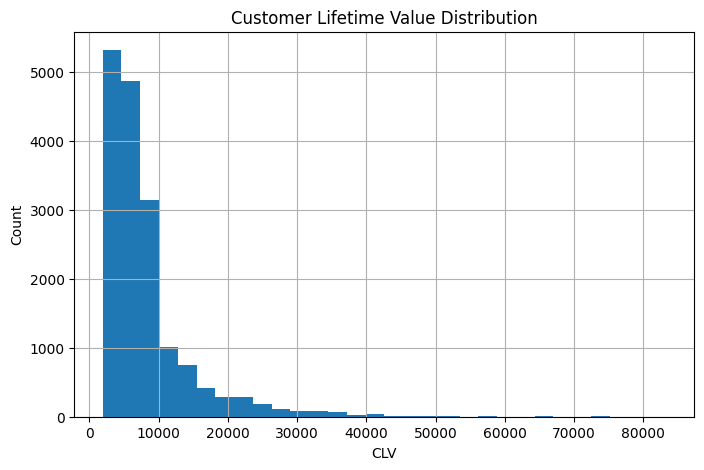

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
customer_df["clv"].hist(bins=30)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Count")
plt.show()

In [14]:
customer_df.groupby("loyalty_card")["clv"].mean().sort_values()

loyalty_card
Star       6741.761372
Nova       8045.615995
Aurora    10672.686325
Name: clv, dtype: float64

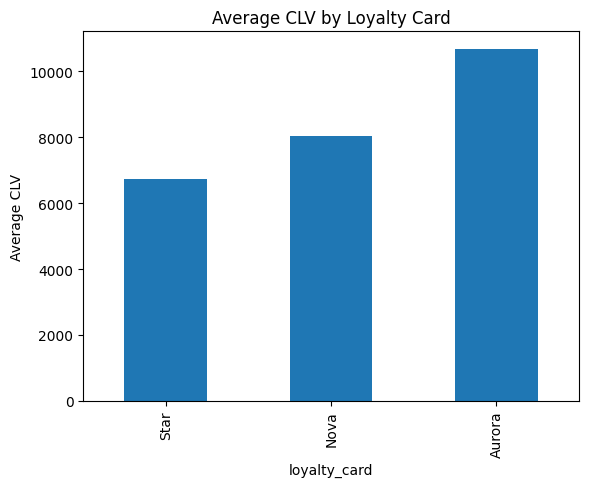

In [15]:
customer_df.groupby("loyalty_card")["clv"].mean().sort_values().plot(kind="bar")
plt.title("Average CLV by Loyalty Card")
plt.ylabel("Average CLV")
plt.show()

In [16]:
pd.crosstab(
    customer_df["loyalty_card"],
    customer_df["churn"],
    normalize="index"
) * 100

churn,0,1
loyalty_card,,
Aurora,86.905803,13.094197
Nova,87.356727,12.643273
Star,88.202174,11.797826


In [17]:
customer_df.to_csv(OUTPUT_DIR / "customer_level_dataset_v1.csv", index=False)
print("Saved customer_level_dataset_v1.csv")

Saved customer_level_dataset_v1.csv
